# GF model (Nowicki Jessee 2018) — aspect rose, M 7.5 Yumare event

Rose diagram of the **slope orientation (aspect) of terrain the USGS Ground Failure
model considers landslide-prone**, for the M 7.5 Yumare mainshock (us6000t7zp,
`data/usgs/ground_failure/jessee_2018_model.tif`, ~230 m cells).

Method (same terrain pipeline as `scripts/fig6_2_aspect_rose.py` and the other
slope/aspect notebooks): model cells at or above `PROB_THRESHOLD` are kept, the
GLO-30 DEM covering them is fetched/cached, warped to UTM 19N, aspect = downslope
azimuth from a Horn-style gradient, sampled at each model cell center; cells
flatter than 2° are excluded (no meaningful aspect).

Unlike the inventory notebooks there is no slope-class stacking — petals are
**weighted and colored by modeled probability** instead.

**`WEST_CUTOFF`** limits the analysis to model cells east of a given longitude
(e.g. `-67.8`); set it to `None` to use the full model footprint.

Caveat: the GF run used a point-source approximation (`point_source: true` in
`info.json`), so spatial detail near the rupture is approximate.

In [8]:
MODEL = "../data/usgs/ground_failure/jessee_2018_model.tif"  # M 7.5 Yumare (us6000t7zp)
WEST_CUTOFF = None#-69.4   # only cells with lon >= this; None = full model footprint
PROB_THRESHOLD = 0.002  # ignore cells below this modeled probability
N_PETALS = 16
MIN_SLOPE_DEG = 2.0    # cells flatter than this have no meaningful aspect

## Load the model grid
Keep finite cells at/above the probability threshold and east of the cutoff.

In [9]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(MODEL) as src:
    prob = src.read(1)
    T = src.transform

mask = np.isfinite(prob) & (prob >= PROB_THRESHOLD)
rows, cols = np.where(mask)
xs, ys = rasterio.transform.xy(T, rows, cols)
lon, lat, p = np.asarray(xs), np.asarray(ys), prob[rows, cols]
if WEST_CUTOFF is not None:
    keep = lon >= WEST_CUTOFF
    lon, lat, p = lon[keep], lat[keep], p[keep]

cut = f", lon >= {WEST_CUTOFF}" if WEST_CUTOFF is not None else ""
print(f"{p.size} model cells retained (p >= {PROB_THRESHOLD}{cut})")
print(f"sum(p) = {p.sum():.0f} cell-probabilities | max p = {p.max():.3f}")
print(f"bounds: lon {lon.min():.2f}..{lon.max():.2f}, lat {lat.min():.2f}..{lat.max():.2f}")

91376 model cells retained (p >= 0.002)
sum(p) = 870 cell-probabilities | max p = 0.211
bounds: lon -69.83..-66.06, lat 9.32..10.96


/var/folders/q0/kxmqm5c95n7cxc6mmqklw1k40000gq/T/ipykernel_76865/1374662076.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  prob = src.read(1)


## DEM → aspect at each model cell
GLO-30 mosaic for the retained-cell bounds (cached in `data/terrain/`, gitignored;
the cache name encodes the bounds, so changing the cutoff fetches a fresh clip).
Warp to UTM 19N, Horn-style gradient, sample aspect/slope at cell centers.

In [10]:
import sys
sys.path.insert(0, "../src")
from geer_venezuela import fetch_dem
from pyproj import Transformer
from rasterio.warp import Resampling, calculate_default_transform, reproject

PAD = 0.02
bounds = (lon.min() - PAD, lat.min() - PAD, lon.max() + PAD, lat.max() + PAD)
dem_path = "../data/terrain/dem_cache_{:.2f}_{:.2f}_{:.2f}_{:.2f}.tif".format(*bounds)
fetch_dem(bounds, dem_path)

UTM = "EPSG:32619"
with rasterio.open(dem_path) as src:
    t, w, h = calculate_default_transform(src.crs, UTM, src.width, src.height, *src.bounds)
    z = np.full((h, w), np.nan, dtype="float32")
    reproject(source=rasterio.band(src, 1), destination=z,
              src_transform=src.transform, src_crs=src.crs,
              dst_transform=t, dst_crs=UTM,
              resampling=Resampling.bilinear, dst_nodata=np.nan)

xres, yres = t.a, -t.e
dzdy_rows, dzdx = np.gradient(z, yres, xres)
dzdy = -dzdy_rows  # positive = elevation increases northward
aspect = (np.degrees(np.arctan2(-dzdx, -dzdy))) % 360.0  # downslope azimuth, CW from N
slope = np.degrees(np.arctan(np.hypot(dzdx, dzdy)))
invalid = ~np.isfinite(z) | (z <= 0)  # sea/no-data: elevation <= 0 is invalid
aspect[invalid] = np.nan
slope[invalid] = np.nan

# sample at model cell centers
to_utm = Transformer.from_crs("EPSG:4326", UTM, always_xy=True)
X, Y = to_utm.transform(lon, lat)
rr, cc = rasterio.transform.rowcol(t, X, Y)
rr, cc = np.asarray(rr), np.asarray(cc)
inside = (rr >= 0) & (rr < h) & (cc >= 0) & (cc < w)
asp = np.full(p.size, np.nan)
slp = np.full(p.size, np.nan)
asp[inside] = aspect[rr[inside], cc[inside]]
slp[inside] = slope[rr[inside], cc[inside]]
ok = np.isfinite(asp) & (slp >= MIN_SLOPE_DEG)
asp_k, p_k = asp[ok], p[ok]
print(f"{ok.sum()} of {p.size} cells with valid aspect (slope >= {MIN_SLOPE_DEG} deg)")
print(f"dropped: {(~np.isfinite(asp)).sum()} off-DEM/sea, "
      f"{(np.isfinite(asp) & (slp < MIN_SLOPE_DEG)).sum()} too flat")

90036 of 91376 cells with valid aspect (slope >= 2.0 deg)
dropped: 339 off-DEM/sea, 1001 too flat


## Probability classes
Stacked-rose classes come from the modeled probability itself (the inventory
notebooks stack by slope class instead).

In [11]:
PROB_BINS = [0.002, 0.005, 0.01, 0.02, 0.05, 1.0]
PROB_LABELS = ["0.002-0.005", "0.005-0.01", "0.01-0.02", "0.02-0.05", ">=0.05"]
# sequential yellow->red: higher probability = hotter
PROB_COLORS = ["#ffffb2", "#fecc5c", "#fd8d3c", "#f03b20", "#bd0026"]
pclass = np.digitize(p_k, PROB_BINS[1:-1])  # 0..4

## Headline: probability-weighted aspect rose

16 petals; petal length = **summed modeled probability** of cells facing that
way (an expected-affected-cells measure), stacked by probability class. Compass
orientation is geographic (N up, clockwise).

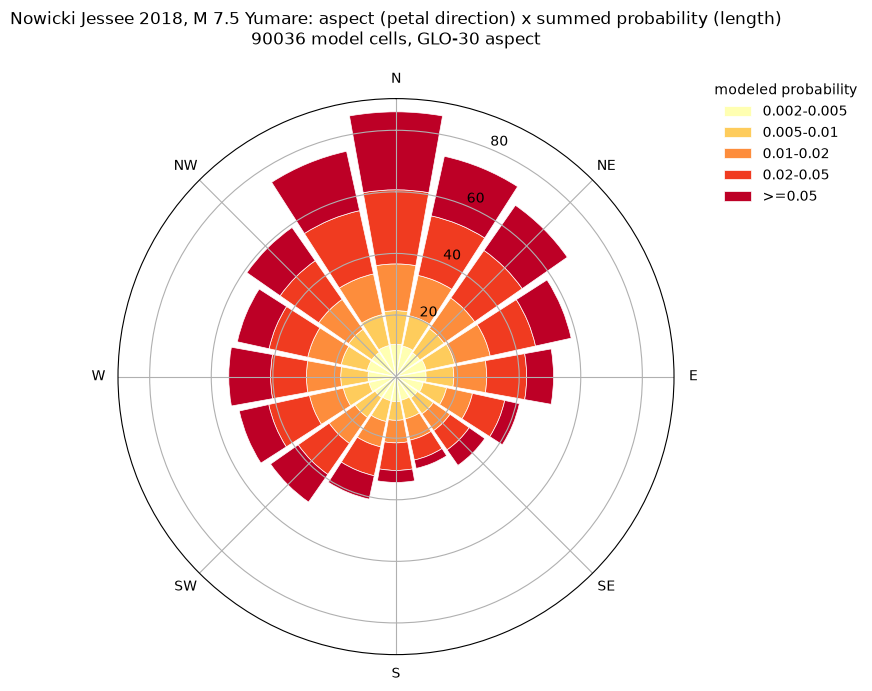

In [12]:
petal_width = 2 * np.pi / N_PETALS
sector = np.floor(((asp_k + (360 / N_PETALS / 2)) % 360) / (360 / N_PETALS)).astype(int)

wsum = np.zeros((N_PETALS, len(PROB_LABELS)))
csum = np.zeros((N_PETALS, len(PROB_LABELS)), dtype=int)
np.add.at(wsum, (sector, pclass), p_k)
np.add.at(csum, (sector, pclass), 1)

theta = np.deg2rad(np.arange(N_PETALS) * (360 / N_PETALS))
cut_note = f" east of {WEST_CUTOFF} deg" if WEST_CUTOFF is not None else ""

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)  # clockwise
bottom = np.zeros(N_PETALS)
for b in range(len(PROB_LABELS)):
    ax.bar(theta, wsum[:, b], width=petal_width * 0.9, bottom=bottom,
           color=PROB_COLORS[b], edgecolor="white", linewidth=0.5,
           label=PROB_LABELS[b])
    bottom += wsum[:, b]
ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_title("Nowicki Jessee 2018, M 7.5 Yumare: aspect (petal direction) x "
             f"summed probability (length)\n{ok.sum()} model cells{cut_note}, "
             "GLO-30 aspect", pad=20)
ax.legend(title="modeled probability", loc="upper left",
          bbox_to_anchor=(1.05, 1.05), frameon=False)
plt.tight_layout()
plt.savefig("jessee75_rose_prob.png", dpi=150, bbox_inches="tight")
plt.show()

## Companion — cell-count rose
Same sectors and classes, but petal length = number of cells (>= threshold).
Shows whether the probability weighting shifts the picture relative to sheer
area of prone terrain.

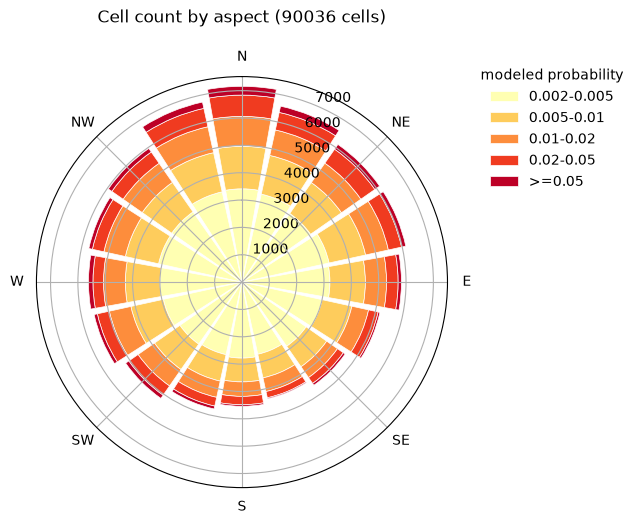

In [13]:
fig = plt.figure(figsize=(6.5, 6.5))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
bottom = np.zeros(N_PETALS)
for b in range(len(PROB_LABELS)):
    ax.bar(theta, csum[:, b], width=petal_width * 0.9, bottom=bottom,
           color=PROB_COLORS[b], edgecolor="white", linewidth=0.5,
           label=PROB_LABELS[b])
    bottom += csum[:, b]
ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
ax.set_title(f"Cell count by aspect ({ok.sum()} cells{cut_note})", pad=20)
ax.legend(title="modeled probability", loc="upper left",
          bbox_to_anchor=(1.05, 1.05), frameon=False)
plt.tight_layout()
plt.savefig("jessee75_rose_count.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary table

In [14]:
import pandas as pd

DIRS8 = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
sector8 = np.floor(((asp_k + 22.5) % 360) / 45).astype(int)
summary = (pd.DataFrame({"dir": np.array(DIRS8)[sector8], "p": p_k})
           .groupby("dir")
           .agg(n_cells=("p", "size"), sum_p=("p", "sum"),
                mean_p=("p", "mean"), max_p=("p", "max"))
           .reindex(DIRS8).round(4))
print(summary)
print(f"\nAll retained cells: n={ok.sum()}, sum(p)={p_k.sum():.1f}, "
      f"max p={p_k.max():.3f}{cut_note}")

     n_cells     sum_p  mean_p   max_p
dir                                   
N      14049  165.1607  0.0118  0.2112
NE     12426  133.6855  0.0108  0.1962
E      11541  100.1747  0.0087  0.1797
SE      9216   69.7429  0.0076  0.1706
S       9094   69.4855  0.0076  0.1354
SW     10298   95.7239  0.0093  0.1846
W      11341  107.0513  0.0094  0.1792
NW     12071  120.0348  0.0099  0.1893

All retained cells: n=90036, sum(p)=861.1, max p=0.211
